<a href="https://colab.research.google.com/github/dzidz1/Freeuni_ML_Walmart_Sales_Forecasting/blob/main/model_experiment_DLinear.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install

In [ ]:
!pip -q install -U kaggle neuralforecast mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 124.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 102.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Imports + Config

In [ ]:
import os
import random
import warnings
from pathlib import Path

import mlflow
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from google.colab import drive, userdata
from neuralforecast import NeuralForecast
from neuralforecast.models import DLinear

warnings.filterwarnings("ignore")

SEED = 42
QUICK_RUN = False
VALIDATION_WEEKS = 13
FREQ = "W-FRI"

MODEL_NAME = "DLinear"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


# Paths + Kaggle Credentials

In [ ]:
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/walmart_final_project")
DATA_DIR = PROJECT_DIR / "data"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / MODEL_NAME.lower()

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_token = userdata.get("KAGGLE_API_TOKEN")

if kaggle_username is None or kaggle_token is None:
    raise ValueError("Colab Secrets-ში KAGGLE_USERNAME ან KAGGLE_API_TOKEN არ ჩანს.")

os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_token

print("DATA_DIR:", DATA_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("Kaggle credentials loaded.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR: /content/drive/MyDrive/walmart_final_project/data
ARTIFACT_DIR: /content/drive/MyDrive/walmart_final_project/artifacts/dlinear
Kaggle credentials loaded.


# Download Competition Data

In [ ]:
competition_name = "walmart-recruiting-store-sales-forecasting"
zip_path = DATA_DIR / f"{competition_name}.zip"

if not zip_path.exists():
    !kaggle competitions download -c {competition_name} -p {DATA_DIR}
else:
    print("Competition zip already exists:", zip_path)

!unzip -o {zip_path} -d {DATA_DIR}

Competition zip already exists: /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
Archive:  /content/drive/MyDrive/walmart_final_project/data/walmart-recruiting-store-sales-forecasting.zip
  inflating: /content/drive/MyDrive/walmart_final_project/data/features.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/sampleSubmission.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/stores.csv  
  inflating: /content/drive/MyDrive/walmart_final_project/data/test.csv.zip  
  inflating: /content/drive/MyDrive/walmart_final_project/data/train.csv.zip  


# Load Data

In [ ]:
train = pd.read_csv(DATA_DIR / "train.csv.zip")
test = pd.read_csv(DATA_DIR / "test.csv.zip")
features = pd.read_csv(DATA_DIR / "features.csv.zip")
stores = pd.read_csv(DATA_DIR / "stores.csv")
sample_submission = pd.read_csv(DATA_DIR / "sampleSubmission.csv.zip")

for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


# Metric + Preprocessing

In [ ]:
def make_unique_id(df):
    return df["Store"].astype(str) + "_" + df["Dept"].astype(str)


def walmart_wmae(y_true, y_pred, is_holiday):
    weights = np.where(pd.Series(is_holiday).astype(bool).to_numpy(), 5, 1)
    errors = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    return float(np.sum(weights * errors) / np.sum(weights))


def build_calendar(train_df, test_df):
    calendar = pd.concat(
        [
            train_df[["Date", "IsHoliday"]],
            test_df[["Date", "IsHoliday"]],
        ],
        ignore_index=True,
    )

    calendar = (
        calendar
        .drop_duplicates("Date")
        .rename(columns={"Date": "ds"})
        .sort_values("ds")
        .reset_index(drop=True)
    )

    return calendar


def prepare_dlinear_frame(raw_train, calendar):
    base = raw_train.copy()
    base["unique_id"] = make_unique_id(base)

    base = base.rename(columns={"Date": "ds", "Weekly_Sales": "y"})
    base = base[["unique_id", "ds", "y"]]

    all_ids = base["unique_id"].drop_duplicates().sort_values()
    all_dates = pd.date_range(base["ds"].min(), base["ds"].max(), freq=FREQ)

    full_grid = (
        pd.MultiIndex
        .from_product([all_ids, all_dates], names=["unique_id", "ds"])
        .to_frame(index=False)
    )

    out = full_grid.merge(base, on=["unique_id", "ds"], how="left")
    out["y"] = out["y"].fillna(0.0)

    out = out.merge(calendar, on="ds", how="left")
    out["IsHoliday"] = out["IsHoliday"].fillna(False).astype(bool)

    return out.sort_values(["unique_id", "ds"]).reset_index(drop=True)

# Build DLinear Dataset

In [ ]:
calendar = build_calendar(train, test)
nf_full = prepare_dlinear_frame(train, calendar)

if QUICK_RUN:
    top_ids = (
        train.assign(unique_id=make_unique_id(train))
        .groupby("unique_id")["Weekly_Sales"]
        .sum()
        .nlargest(120)
        .index
    )

    nf_full = nf_full[nf_full["unique_id"].isin(top_ids)].copy()

print("series:", nf_full["unique_id"].nunique())
print("date range:", nf_full["ds"].min().date(), "to", nf_full["ds"].max().date())
print("rows:", len(nf_full))

nf_full.head()

series: 3331
date range: 2010-02-05 to 2012-10-26
rows: 476333


,unique_id,ds,y,IsHoliday
0,10_1,2010-02-05,40212.84,False
1,10_1,2010-02-12,67699.32,True
2,10_1,2010-02-19,49748.33,False
3,10_1,2010-02-26,33601.22,False
4,10_1,2010-03-05,36572.44,False


# MLflow + DagsHub

In [ ]:
DAGSHUB_USERNAME = "mgior23"
DAGSHUB_REPO_OWNER = "adzid23"
DAGSHUB_REPO_NAME = "Freeuni_ML_Walmart_Sales_Forecasting"

dagshub_token = userdata.get("DAGSHUB_TOKEN")

if dagshub_token is None:
    raise ValueError("Colab Secrets-ში DAGSHUB_TOKEN არ ჩანს.")

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_REPO_OWNER}/{DAGSHUB_REPO_NAME}.mlflow"
)

if mlflow.active_run():
    mlflow.end_run()

mlflow.set_experiment("DLinear_Training")

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment: DLinear_Training")

MLflow tracking URI: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow
Experiment: DLinear_Training


# Log Preprocessing + Model Setup Runs

In [ ]:
with mlflow.start_run(run_name="DLinear_Preprocessing"):
    mlflow.log_params({
        "model_family": "Deep Learning",
        "architecture": "DLinear",
        "frequency": FREQ,
        "missing_week_strategy": "fill_missing_sales_with_zero",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
    })

    mlflow.log_metrics({
        "n_series": nf_full["unique_id"].nunique(),
        "n_rows": len(nf_full),
        "n_dates": nf_full["ds"].nunique(),
    })

with mlflow.start_run(run_name="DLinear_Feature_Setup"):
    mlflow.log_params({
        "forecasting_type": "global_univariate_forecaster",
        "target": "Weekly_Sales",
        "external_features_used": False,
        "holiday_used_for_metric_only": True,
    })

print("DLinear preprocessing/setup runs logged.")

🏃 View run DLinear_Preprocessing at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3/runs/2d9eaedccc3e40a28691a350a407a5df
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3
🏃 View run DLinear_Feature_Setup at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3/runs/a9eda88fbb1a4eefacad001af364fc75
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3
DLinear preprocessing/setup runs logged.


# Validation Split

In [ ]:
last_train_date = nf_full["ds"].max()
valid_start = last_train_date - pd.Timedelta(weeks=VALIDATION_WEEKS - 1)

train_part = nf_full[nf_full["ds"] < valid_start][["unique_id", "ds", "y"]].copy()
valid_part = nf_full[nf_full["ds"] >= valid_start].copy()

print("train_part:", train_part.shape)
print("valid_part:", valid_part.shape)
print("validation start:", valid_start.date())

valid_part.head()

train_part: (433030, 3)
valid_part: (43303, 4)
validation start: 2012-08-03


,unique_id,ds,y,IsHoliday
130,10_1,2012-08-03,26390.26,False
131,10_1,2012-08-10,26320.29,False
132,10_1,2012-08-17,26752.40,False
133,10_1,2012-08-24,26804.84,False
134,10_1,2012-08-31,26083.28,False


# Train DLinear Baseline

In [ ]:
run_suffix = "Quick" if QUICK_RUN else "Full"

BASELINE_INPUT_SIZE = 52
BASELINE_STEPS = 100 if QUICK_RUN else 1500

baseline_model = DLinear(
    h=VALIDATION_WEEKS,
    input_size=BASELINE_INPUT_SIZE,
    max_steps=BASELINE_STEPS,
    scaler_type="robust",
    learning_rate=1e-3,
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

baseline_engine = NeuralForecast(models=[baseline_model], freq=FREQ)

with mlflow.start_run(run_name=f"DLinear_Training_Baseline_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "DLinear",
        "run_type": "baseline",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": BASELINE_INPUT_SIZE,
        "max_steps": BASELINE_STEPS,
        "scaler_type": "robust",
        "learning_rate": 1e-3,
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    baseline_engine.fit(df=train_part)
    baseline_pred = baseline_engine.predict()

    baseline_scored = valid_part.merge(baseline_pred, on=["unique_id", "ds"], how="inner")
    baseline_scored["DLinear"] = baseline_scored["DLinear"].clip(lower=0)

    baseline_wmae = walmart_wmae(
        baseline_scored["y"],
        baseline_scored["DLinear"],
        baseline_scored["IsHoliday"]
    )

    mlflow.log_metric("validation_wmae", baseline_wmae)

    baseline_path = ARTIFACT_DIR / "baseline_model"
    baseline_engine.save(
        path=str(baseline_path),
        model_index=None,
        overwrite=True,
        save_dataset=False
    )

    mlflow.log_artifacts(str(baseline_path), artifact_path="model")

    baseline_scored_path = ARTIFACT_DIR / "baseline_validation_predictions.csv"
    baseline_scored.to_csv(baseline_scored_path, index=False)
    mlflow.log_artifact(str(baseline_scored_path), artifact_path="validation")

    dlinear_baseline_run_id = run.info.run_id

print("DLinear baseline WMAE:", round(baseline_wmae, 4))
print("Run ID:", dlinear_baseline_run_id)

baseline_scored.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 689    | train
8 | linear_season       | Linear        | 689    | train
------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1500` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Training_Baseline_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3/runs/e97b30dbc5c741bc93af8c2b721f1e54
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3
DLinear baseline WMAE: 1569.6958
Run ID: e97b30dbc5c741bc93af8c2b721f1e54


,unique_id,ds,y,IsHoliday,DLinear
0,10_1,2012-08-03,26390.26,False,26392.890625
1,10_1,2012-08-10,26320.29,False,30591.476562
2,10_1,2012-08-17,26752.40,False,32276.396484
3,10_1,2012-08-24,26804.84,False,35579.089844
4,10_1,2012-08-31,26083.28,False,28594.318359


# Visual Inspection

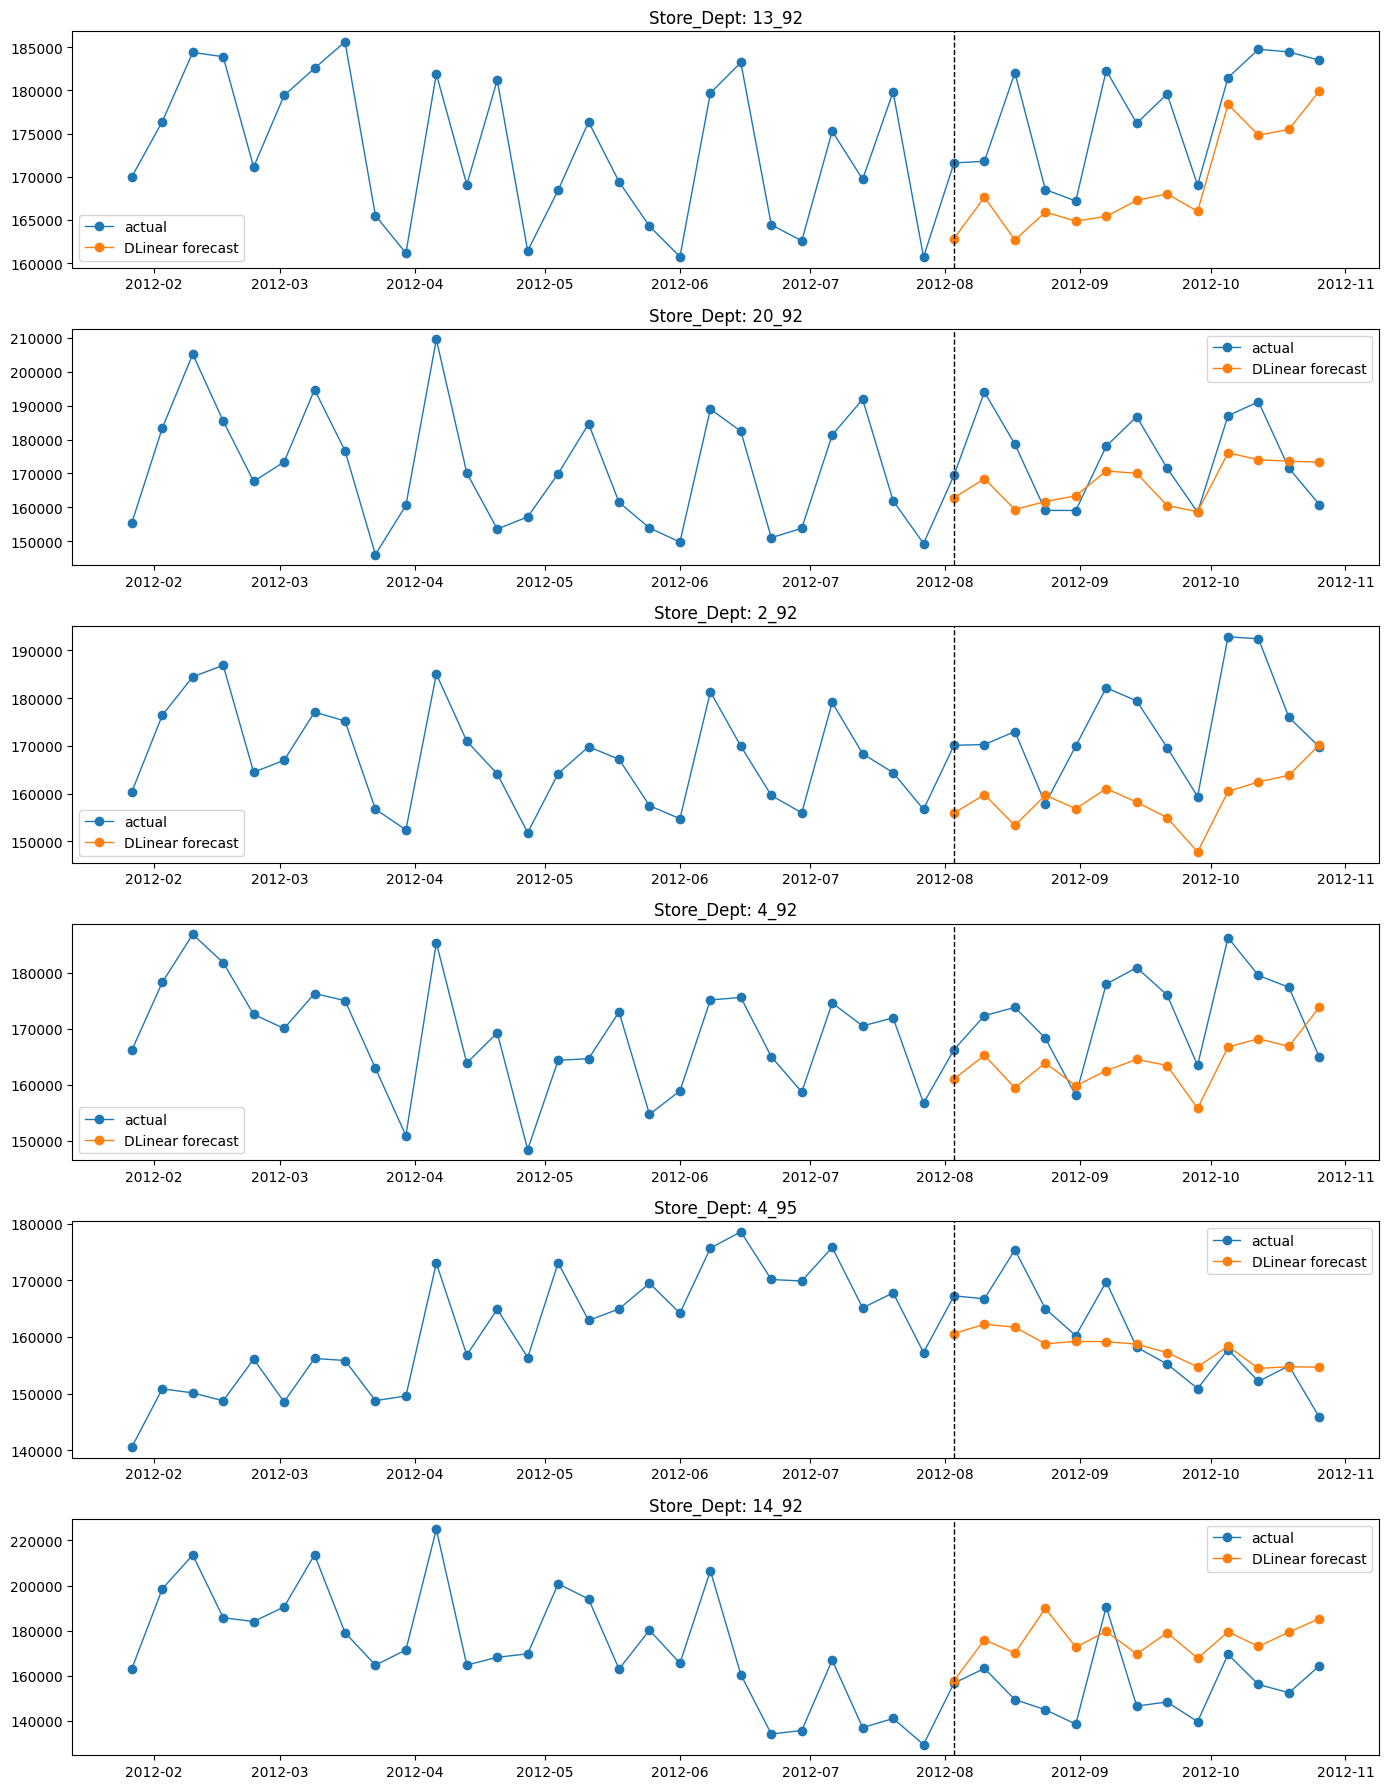

🏃 View run DLinear_Validation_Visualization_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3/runs/a071783ee8ea4681bfc280d7489a0605
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3
DLinear validation plot logged.


In [ ]:
plot_ids = baseline_scored.groupby("unique_id")["y"].sum().nlargest(6).index

fig, axes = plt.subplots(len(plot_ids), 1, figsize=(14, 3 * len(plot_ids)), sharex=False)

if len(plot_ids) == 1:
    axes = [axes]

for ax, uid in zip(axes, plot_ids):
    hist = nf_full[nf_full["unique_id"] == uid].tail(40)
    val = baseline_scored[baseline_scored["unique_id"] == uid]

    ax.plot(hist["ds"], hist["y"], label="actual", marker="o", linewidth=1)
    ax.plot(val["ds"], val["DLinear"], label="DLinear forecast", marker="o", linewidth=1)
    ax.axvline(valid_start, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Store_Dept: {uid}")
    ax.legend()

plt.tight_layout()

plot_path = ARTIFACT_DIR / f"baseline_validation_plot_{run_suffix.lower()}.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

with mlflow.start_run(run_name=f"DLinear_Validation_Visualization_{run_suffix}"):
    mlflow.log_param("source_run_id", dlinear_baseline_run_id)
    mlflow.log_artifact(str(plot_path), artifact_path="plots")

print("DLinear validation plot logged.")

# Tuning Run

In [ ]:
TUNING_INPUT_SIZE = 78
TUNING_STEPS = 150 if QUICK_RUN else 2000
TUNING_LEARNING_RATE = 5e-4

tuned_model = DLinear(
    h=VALIDATION_WEEKS,
    input_size=TUNING_INPUT_SIZE,
    max_steps=TUNING_STEPS,
    scaler_type="standard",
    learning_rate=TUNING_LEARNING_RATE,
    random_seed=SEED,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    enable_progress_bar=True,
)

tuned_engine = NeuralForecast(models=[tuned_model], freq=FREQ)

with mlflow.start_run(run_name=f"DLinear_Tuning_Input78_StandardScaler_{run_suffix}") as run:
    mlflow.log_params({
        "architecture": "DLinear",
        "run_type": "hyperparameter_tuning",
        "quick_run": QUICK_RUN,
        "validation_weeks": VALIDATION_WEEKS,
        "input_size": TUNING_INPUT_SIZE,
        "max_steps": TUNING_STEPS,
        "scaler_type": "standard",
        "learning_rate": TUNING_LEARNING_RATE,
        "frequency": FREQ,
        "n_series": train_part["unique_id"].nunique(),
    })

    tuned_engine.fit(df=train_part)
    tuned_pred = tuned_engine.predict()

    tuned_scored = valid_part.merge(tuned_pred, on=["unique_id", "ds"], how="inner")
    tuned_scored["DLinear"] = tuned_scored["DLinear"].clip(lower=0)

    tuned_wmae = walmart_wmae(
        tuned_scored["y"],
        tuned_scored["DLinear"],
        tuned_scored["IsHoliday"]
    )

    mlflow.log_metric("validation_wmae", tuned_wmae)

    tuned_path = ARTIFACT_DIR / "input78_standard_model"
    tuned_engine.save(
        path=str(tuned_path),
        model_index=None,
        overwrite=True,
        save_dataset=False
    )

    mlflow.log_artifacts(str(tuned_path), artifact_path="model")

    tuned_scored_path = ARTIFACT_DIR / "input78_standard_validation_predictions.csv"
    tuned_scored.to_csv(tuned_scored_path, index=False)
    mlflow.log_artifact(str(tuned_scored_path), artifact_path="validation")

    dlinear_tuning_run_id = run.info.run_id

print("DLinear tuned WMAE:", round(tuned_wmae, 4))
print("Run ID:", dlinear_tuning_run_id)

tuned_scored.head()

INFO:lightning_fabric.utilities.seed:Seed set to 42
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | decomp              | SeriesDecomp  | 0      | train
7 | linear_trend        | Linear        | 1.0 K  | train
8 | linear_season       | Linear        | 1.0 K  | train
------------------

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=2000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

🏃 View run DLinear_Tuning_Input78_StandardScaler_Full at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3/runs/0ace401793bd4b1a99a5d1a2a9ce27e8
🧪 View experiment at: https://dagshub.com/adzid23/Freeuni_ML_Walmart_Sales_Forecasting.mlflow/#/experiments/3
DLinear tuned WMAE: 1153.1571
Run ID: 0ace401793bd4b1a99a5d1a2a9ce27e8


,unique_id,ds,y,IsHoliday,DLinear
0,10_1,2012-08-03,26390.26,False,27589.320312
1,10_1,2012-08-10,26320.29,False,28445.792969
2,10_1,2012-08-17,26752.40,False,27348.632812
3,10_1,2012-08-24,26804.84,False,27227.171875
4,10_1,2012-08-31,26083.28,False,27541.318359


# Comparison Table

In [ ]:
runs = mlflow.search_runs(experiment_names=["DLinear_Training"])

cols = [
    "tags.mlflow.runName",
    "metrics.validation_wmae",
    "params.run_type",
    "params.input_size",
    "params.max_steps",
    "params.scaler_type",
    "params.learning_rate",
    "params.quick_run",
]

available_cols = [col for col in cols if col in runs.columns]

comparison = (
    runs[available_cols]
    .dropna(subset=["metrics.validation_wmae"])
    .sort_values("metrics.validation_wmae")
)

comparison

,tags.mlflow.runName,metrics.validation_wmae,params.run_type,params.input_size,params.max_steps,params.scaler_type,params.learning_rate,params.quick_run
0,DLinear_Tuning_Input78_StandardScaler_Full,1153.157104,hyperparameter_tuning,78,2000,standard,0.0005,False
2,DLinear_Training_Baseline_Full,1569.695809,baseline,52,1500,robust,0.001,False
5,DLinear_Tuning_Input78_StandardScaler_Quick,5975.259572,hyperparameter_tuning,78,150,standard,0.0005,True
7,DLinear_Training_Baseline_Quick,6175.069092,baseline,52,100,robust,0.001,True
